<a href="https://colab.research.google.com/github/vivekjain060305-coder/Wine_Quality_Prerdiction/blob/main/wqp_polynomial_regressionipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving wine-quality-white-and-red (1).csv to wine-quality-white-and-red (1) (1).csv

Results for 70-30 Split
Accuracy: 82.51282051282051
Precision Score: 0.6104651162790697
F1 Score: 0.3811252268602541
AUC Score: 0.8350579181705348


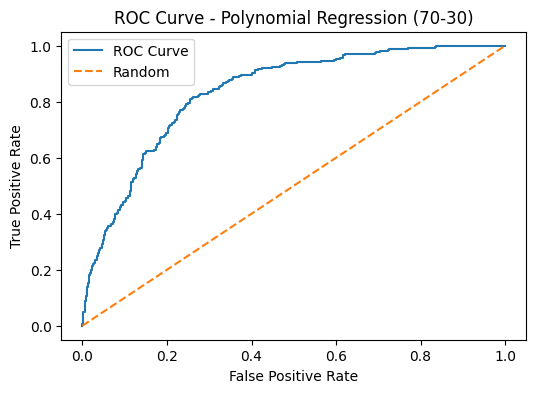

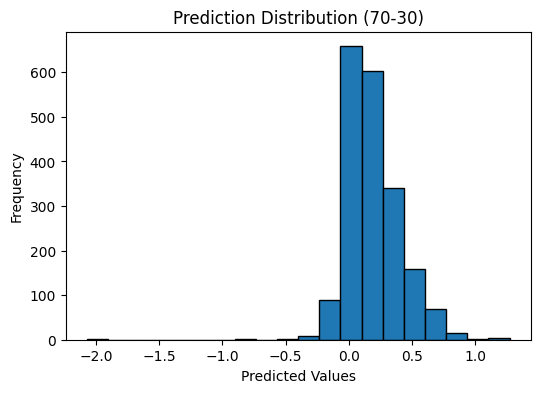


Results for 80-20 Split
Accuracy: 82.23076923076923
Precision Score: 0.5948275862068966
F1 Score: 0.37398373983739835
AUC Score: 0.8540229754880309


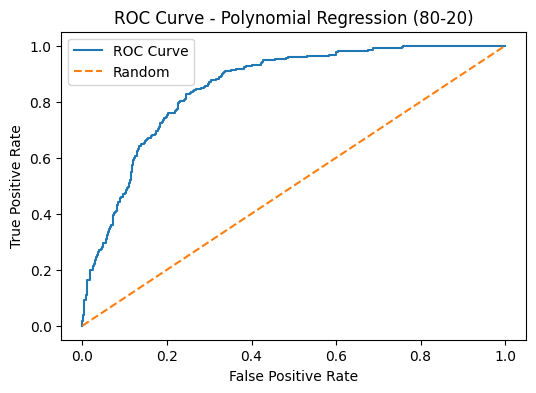

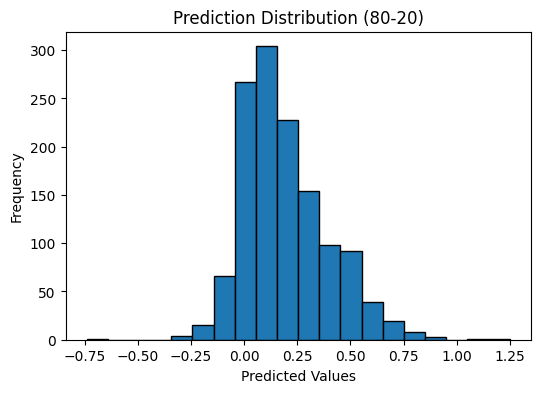

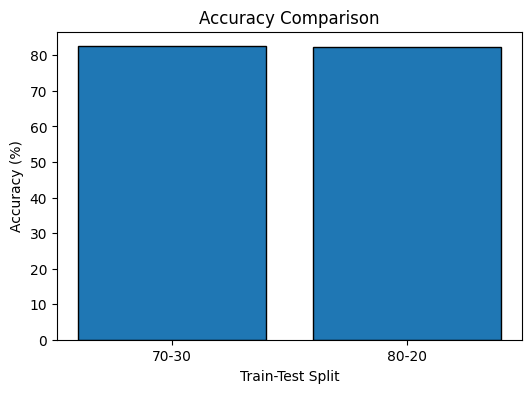

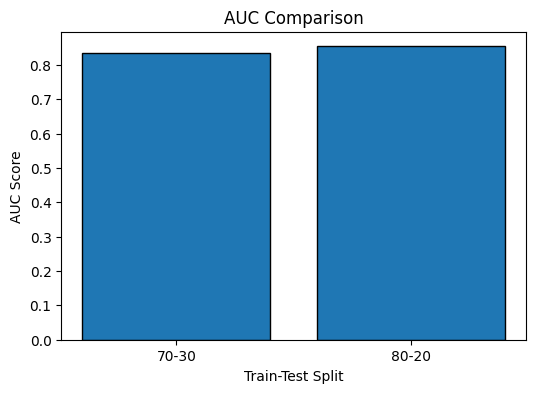

In [ ]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, precision_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score

# Step 2: Upload dataset
from google.colab import files
uploaded = files.upload()

# Step 3: Load dataset
df = pd.read_csv("wine-quality-white-and-red (1).csv")

# Step 4: Create binary label
df["quality_label"] = (df["quality"] >= 7).astype(int)

# Step 5: Features and target
X = df.drop(["quality", "quality_label"], axis=1)
y = df["quality_label"]

# Step 6: One-hot encode categorical column
X = pd.get_dummies(X, columns=['type'], drop_first=True)

# Step 7: Define splits
splits = {
    "70-30": 0.3,
    "80-20": 0.2
}

# Store results for comparison graph
split_names = []
accuracy_list = []
precision_list = []
f1_list = []
auc_list = []

# Step 8: Run model for both splits
for split_name, test_size in splits.items():
    print("\n==============================")
    print(f"Results for {split_name} Split")
    print("==============================")

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # Feature scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Polynomial features
    poly = PolynomialFeatures(degree=2)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Train model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Predict
    y_pred_prob = model.predict(X_test_poly)
    y_pred = (y_pred_prob >= 0.5).astype(int)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred) * 100
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_prob)

    print("Accuracy:", accuracy)
    print("Precision Score:", precision)
    print("F1 Score:", f1)
    print("AUC Score:", auc_score)

    # Save metrics
    split_names.append(split_name)
    accuracy_list.append(accuracy)
    precision_list.append(precision)
    f1_list.append(f1)
    auc_list.append(auc_score)

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label="ROC Curve")
    plt.plot([0, 1], [0, 1], linestyle='--', label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - Polynomial Regression ({split_name})")
    plt.legend()
    plt.show()

    # Prediction distribution graph
    plt.figure(figsize=(6,4))
    plt.hist(y_pred_prob, bins=20, edgecolor='black')
    plt.xlabel("Predicted Values")
    plt.ylabel("Frequency")
    plt.title(f"Prediction Distribution ({split_name})")
    plt.show()

# Step 9: Accuracy comparison graph
plt.figure(figsize=(6,4))
plt.bar(split_names, accuracy_list, edgecolor='black')
plt.xlabel("Train-Test Split")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison")
plt.show()

# Step 10: AUC comparison graph
plt.figure(figsize=(6,4))
plt.bar(split_names, auc_list, edgecolor='black')
plt.xlabel("Train-Test Split")
plt.ylabel("AUC Score")
plt.title("AUC Comparison")
plt.show()